<a href="https://colab.research.google.com/github/MaxHolikov/DataScience/blob/main/hw5/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лог-файл успешно очищен.
   Unnamed: 0    brand           model  color registration_date  year  \
0       75721     ford       Ford Kuga  black           05/2023  2023   
1       80184  hyundai     Hyundai i10  black           09/2018  2018   
2       19864     audi  Audi Q4 e-tron   grey           05/2021  2021   
3       76699    honda      Honda CR-V    red           07/2018  2018   

  price_in_euro power_kw power_ps transmission_type fuel_type  \
0         38490      140      190         Automatic    Hybrid   
1         11555       49       67            Manual    Petrol   
2         48886      125      170         Automatic  Electric   
3         24490      114      155         Automatic    Petrol   

  fuel_consumption_l_100km fuel_consumption_g_km  mileage_in_km  \
0             5,4 l/100 km              124 g/km          100.0   
1             4,6 l/100 km              106 g/km        27782.0   
2                      NaN                0 g/km         4247.0   
3             7

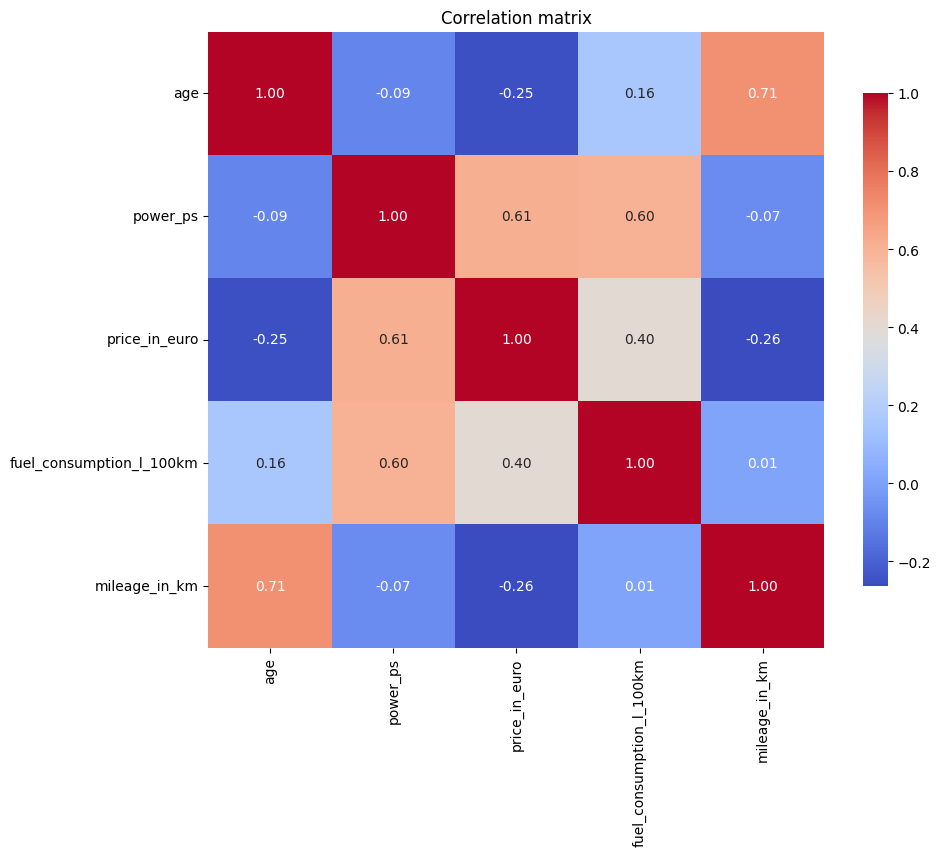

Количество пропущенных значений: 0
Содержимое лог-файла:
2026-03-08 15:57:31 - INFO - File: .csv загружен
2026-03-08 16:00:17 - INFO - Пропусков в расходе ДО заполнения: 11932
2026-03-08 16:00:17 - INFO - Пропусков в расходе ПОСЛЕ заполнения: 0
2026-03-08 16:00:18 - INFO - Оттредактированные данные сохранены в файл 'cleaned_data.csv'.


In [ ]:
#pip install kaggle
#https://www.kaggle.com/datasets/sarametawea/car-data
import get_dataset as gd
import logger as lg
from data_processing import DataProcessing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer

lg.clear_log_file()
my_results_dict = {}

file_path='gcar_data.csv'
try:
    df = pd.read_csv(file_path)
    lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
    lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

processing= DataProcessing(df)
processing.print_file()
missing_values = processing.count_missing()   # количество пропущенных значений
processing.missing_report()

processing.del_model()                        # удаление излишних признаков

processing.col_to_numeric('year')
processing.col_to_numeric('price_in_euro')
processing.col_to_numeric('power_ps')
processing.consumption_to_numeric('fuel_consumption_l_100km')
processing.print_file()

missing_values = processing.count_missing()

processing.missing_report()

processing.remove_null_values()

processing.change_year()

missing_values = processing.count_missing()

processing.missing_report()

#матрица корреляции для понимания, чо делать с расходом топлива на электромобили(в датасете пропущены значения)
numeric_cols = ['age',
                'power_ps',
                'price_in_euro',
                'fuel_consumption_l_100km',
                'mileage_in_km']

data_num = processing.data[numeric_cols]
knn_imputer = KNNImputer(n_neighbors=5)
filled_data_knn = knn_imputer.fit_transform(data_num)
filled_data = pd.DataFrame(filled_data_knn, columns=numeric_cols)
correlation_matrix = filled_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation matrix')
plt.show()

# заполнение расхода электромобилей методом k-ближайших соседей, приведение к топливу
processing.impute_and_merge_consumption(n_neighbors=5)

missing_values = processing.count_missing()

processing.data.to_csv('cleaned_data.csv', index=False)   # сохранение отредактированных данных в файл
lg.log_event("INFO", "Оттредактированные данные сохранены в файл 'cleaned_data.csv'.")


if __name__ == "__main__":
    lg.read_log_file()


Лог-файл успешно очищен.
age  | outliers percent -  3.352313738070414
power_ps  | outliers percent -  7.639947068730452
price_in_euro  | outliers percent -  2.4981955249017562
fuel_consumption_l_100km  | outliers percent -  5.344437589965042
mileage_in_km  | outliers percent -  1.8764137363767222


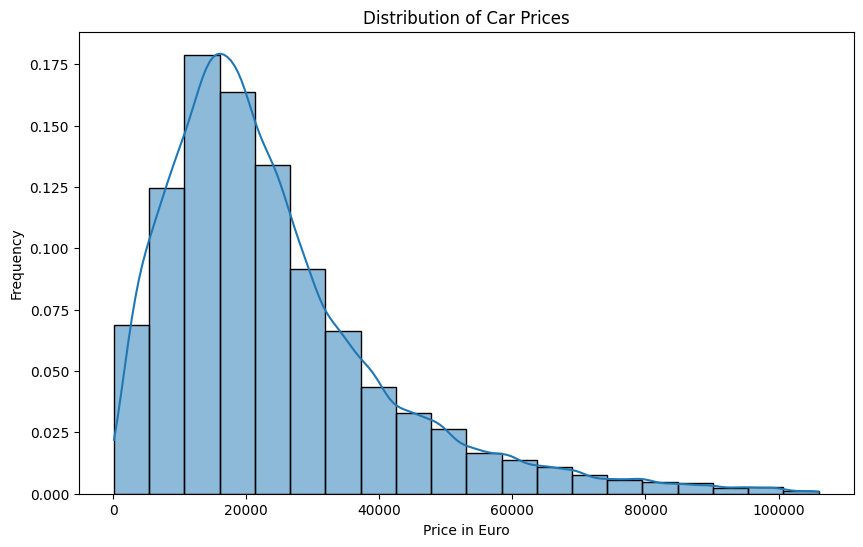

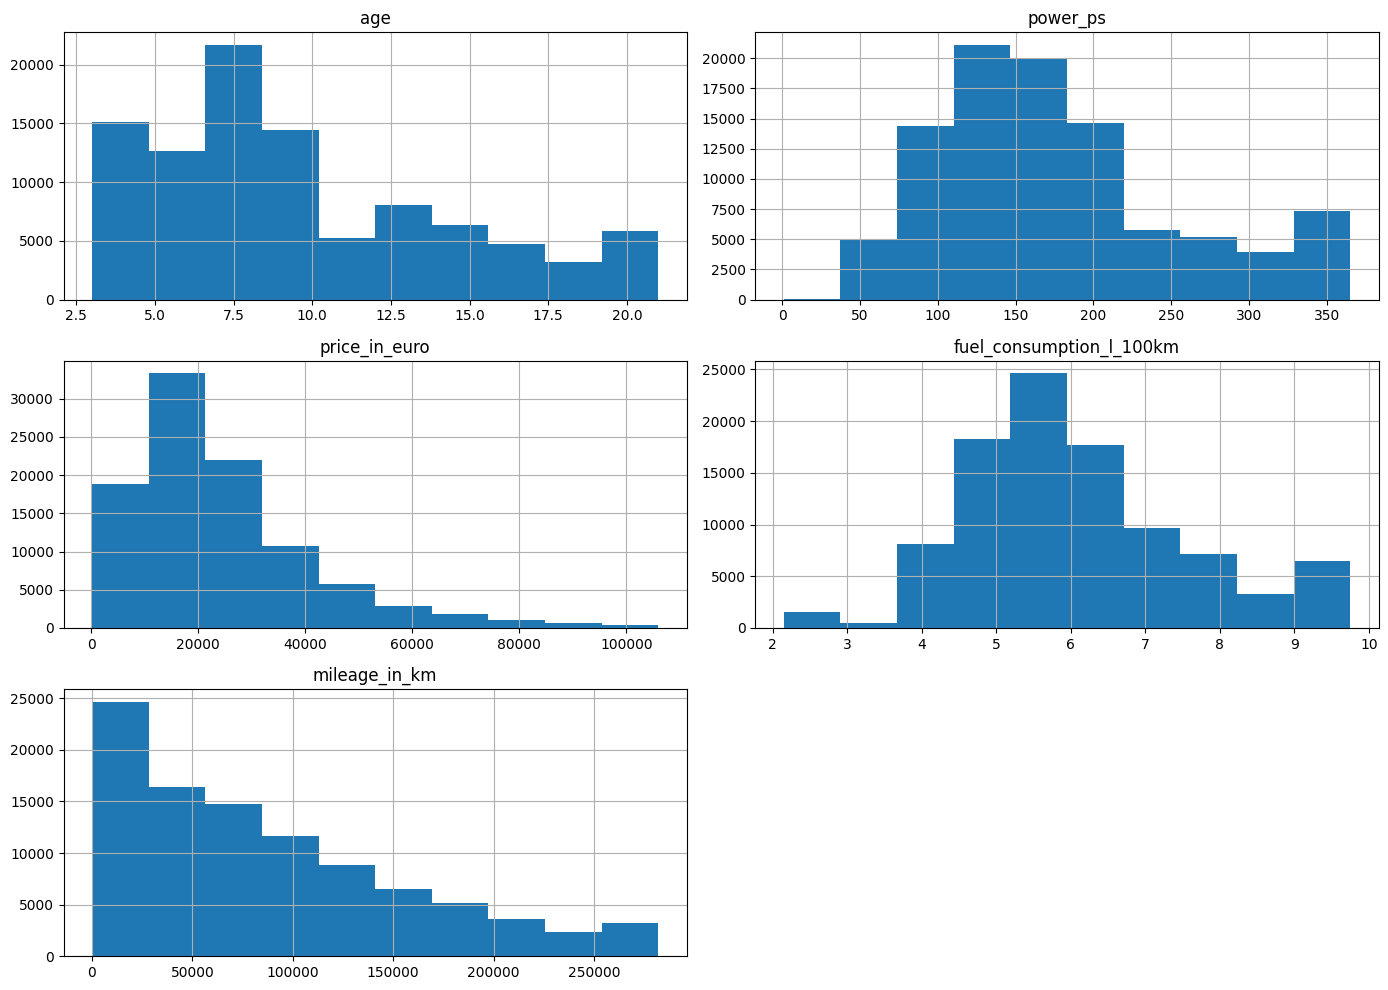

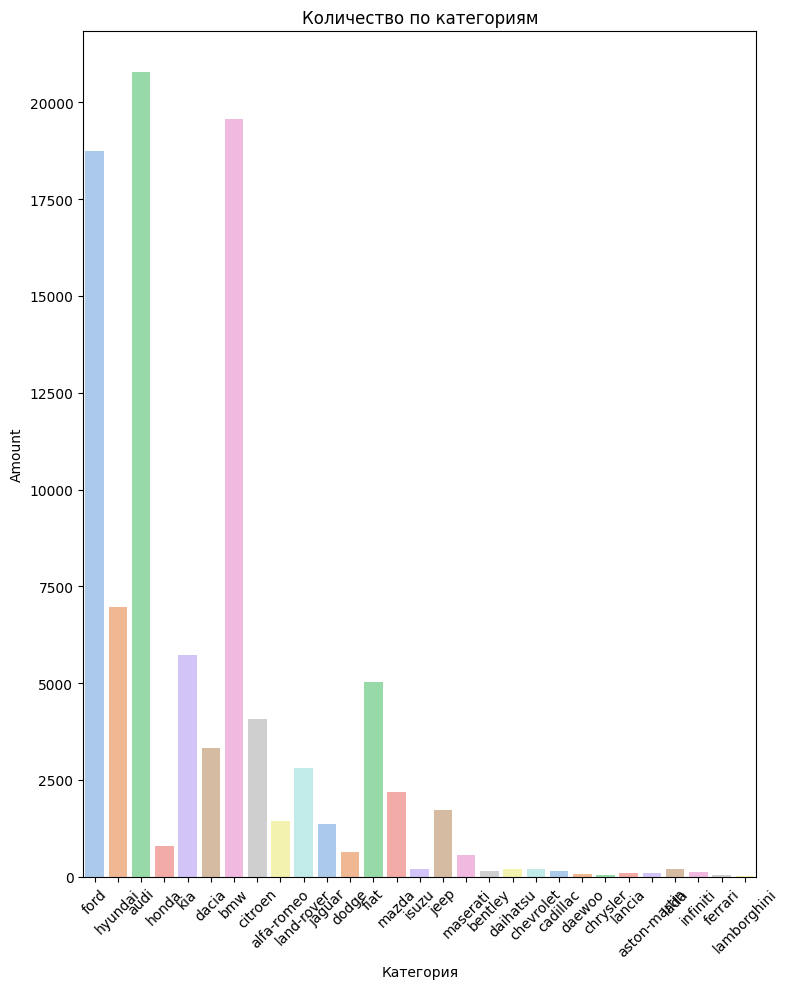

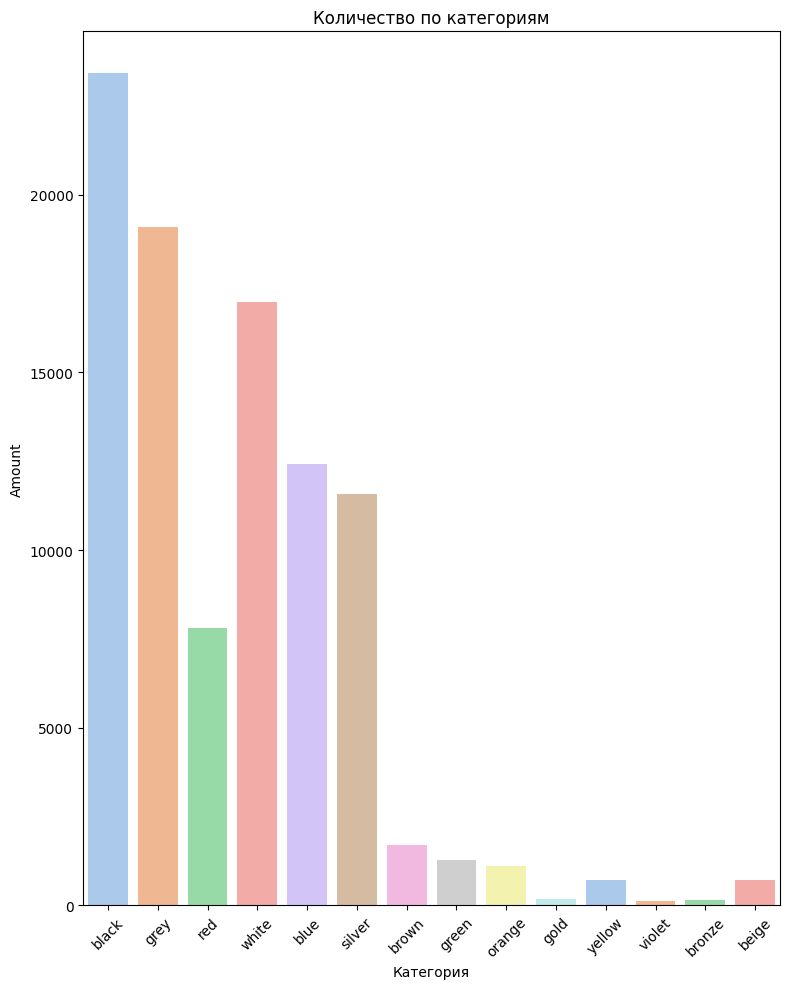

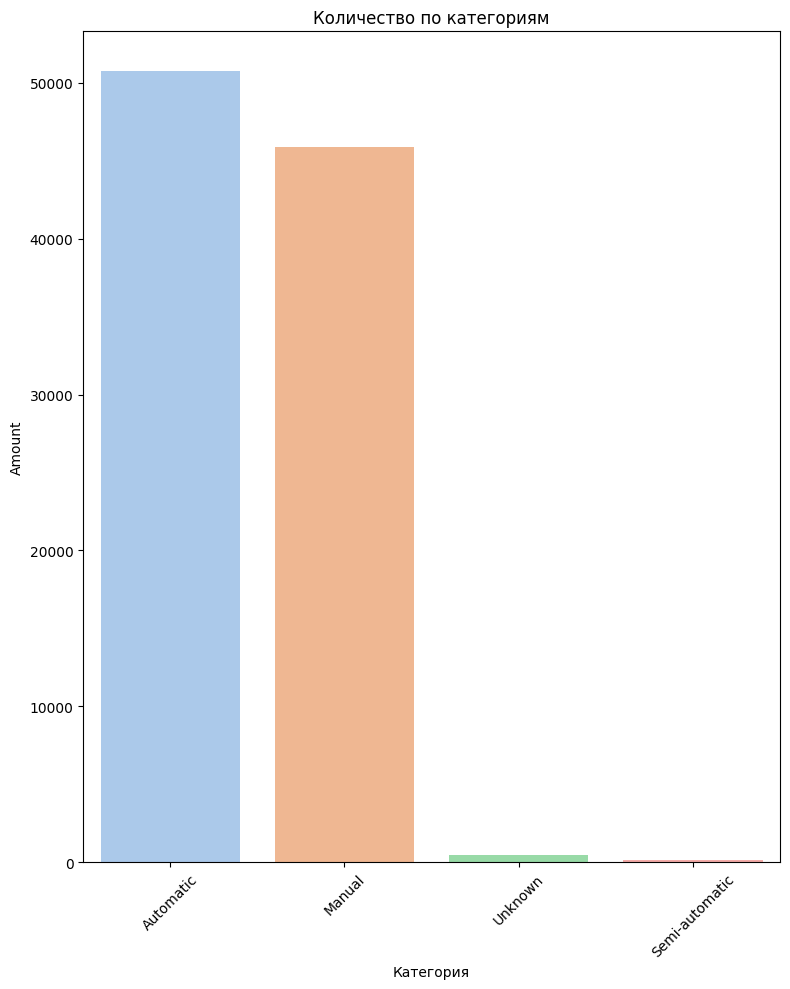

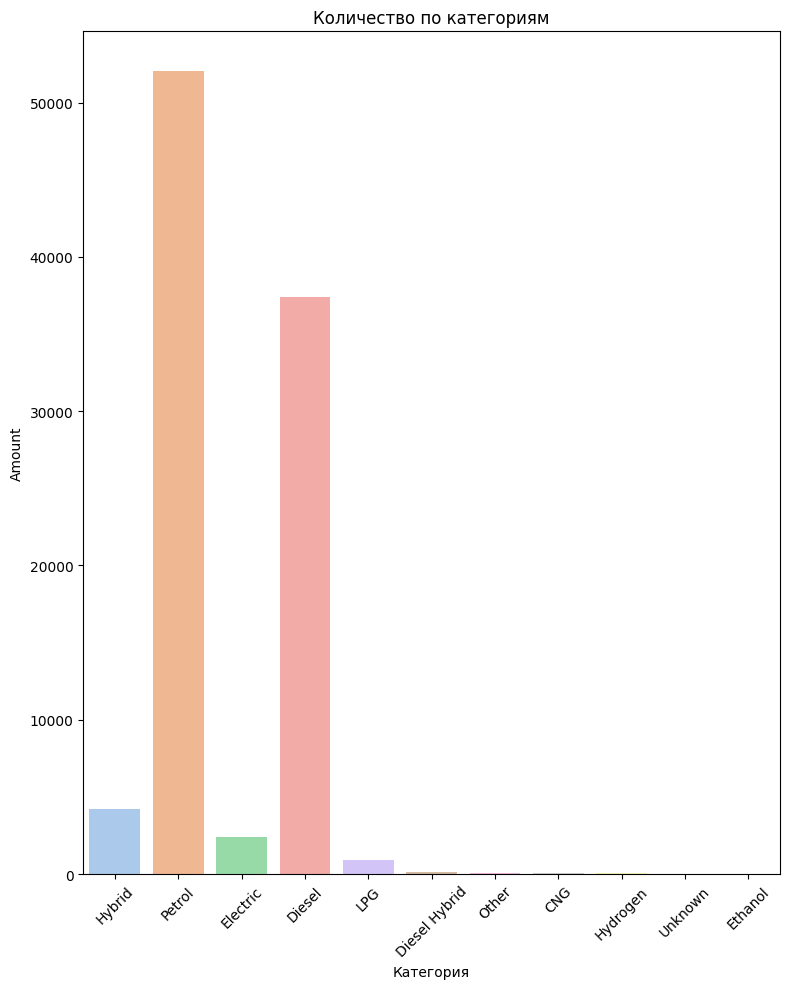

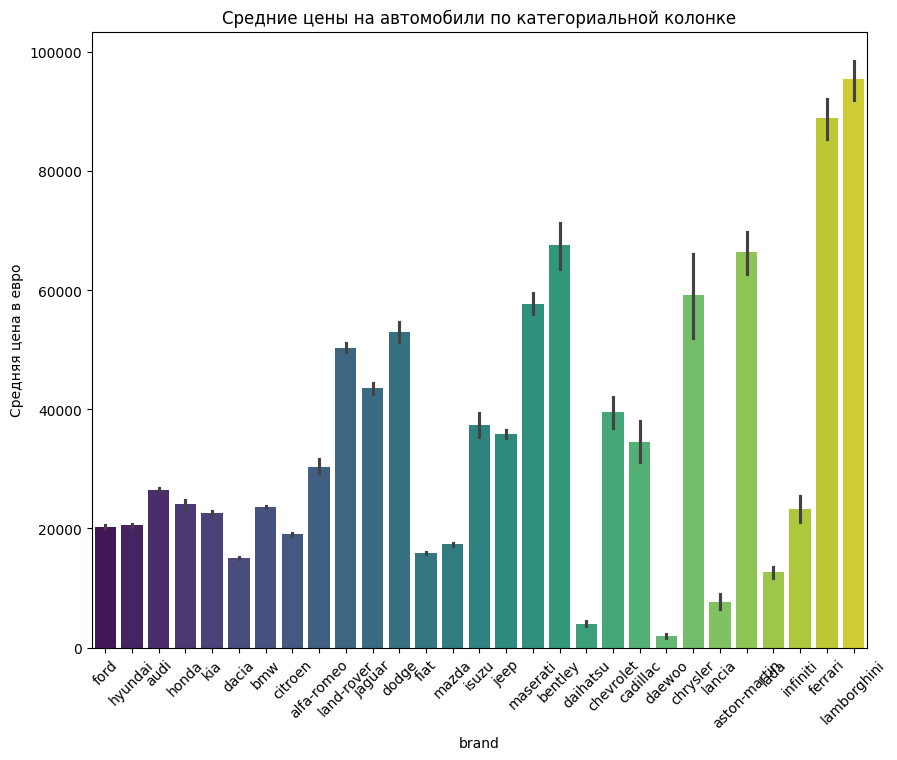

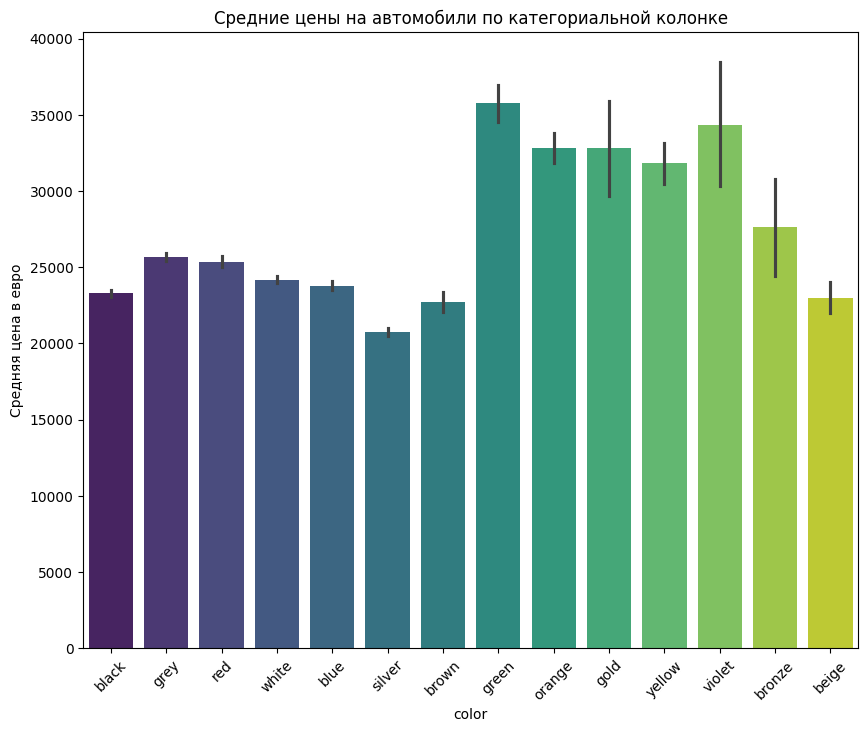

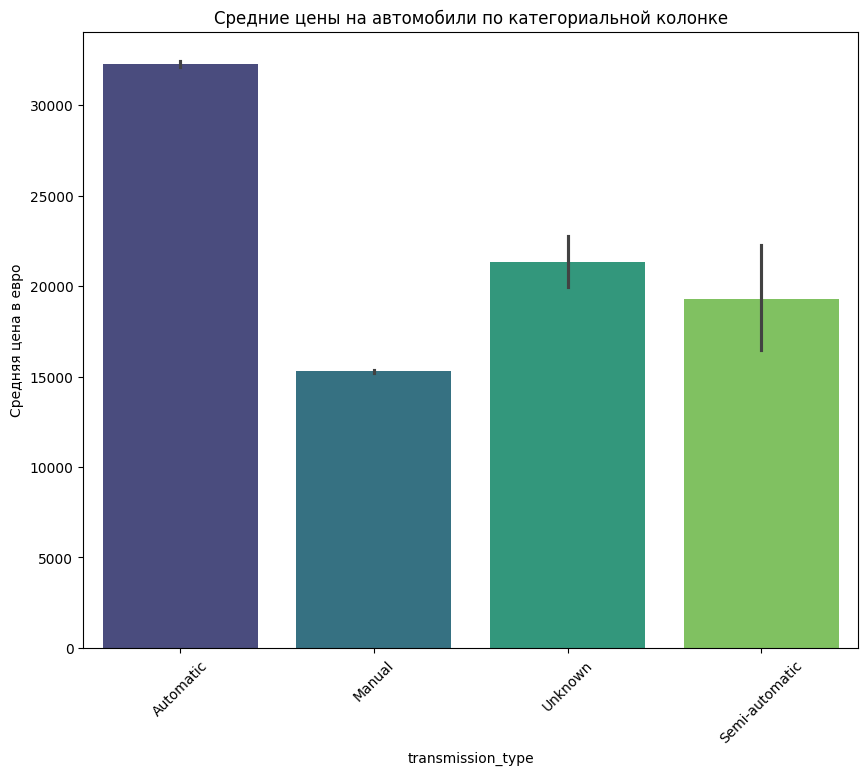

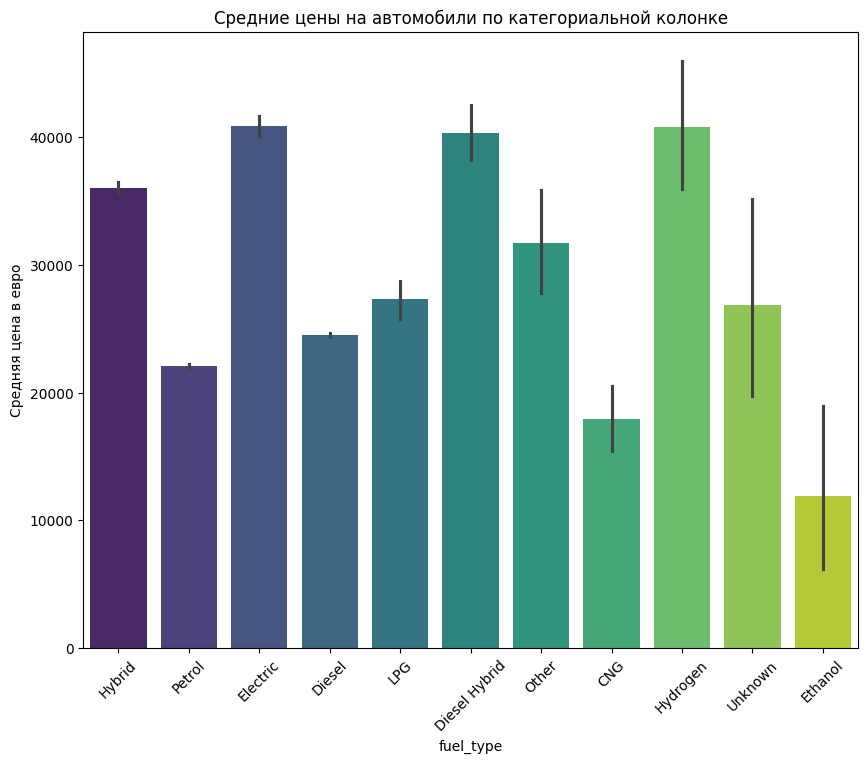

0    0.770337
Name: R2, dtype: float64
Model: LinearRegression
R²: 0.770337069725441, RMSE: 8172.682160928557, MAE: 5443.226758082331


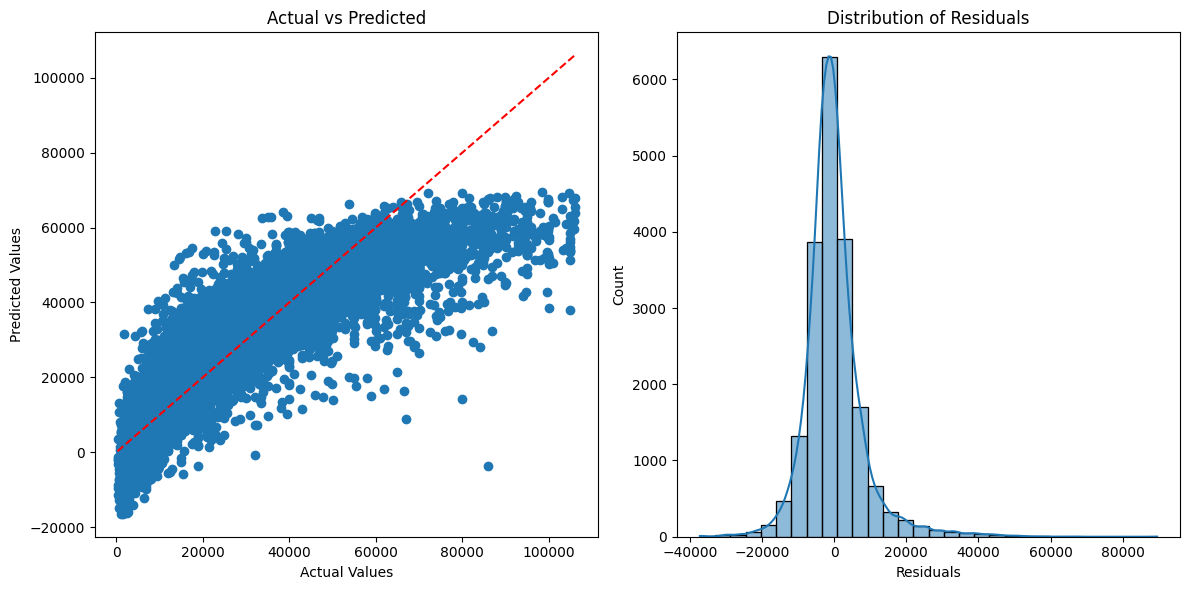

0    0.815671
Name: R2, dtype: float64
Model: DecisionTreeRegressor
R²: 0.8156710331429866, RMSE: 7321.7678213107865, MAE: 4012.8942600017667


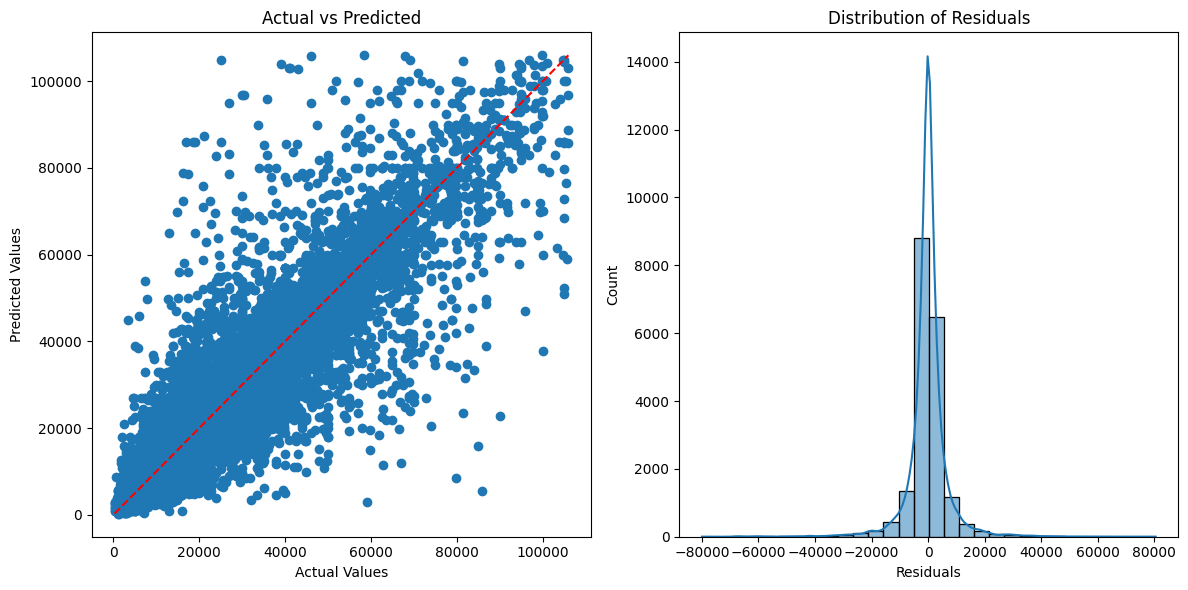

0    0.904214
Name: R2, dtype: float64
Model: RandomForestRegressor
R²: 0.904213641137842, RMSE: 5278.01950520512, MAE: 2940.542652868186


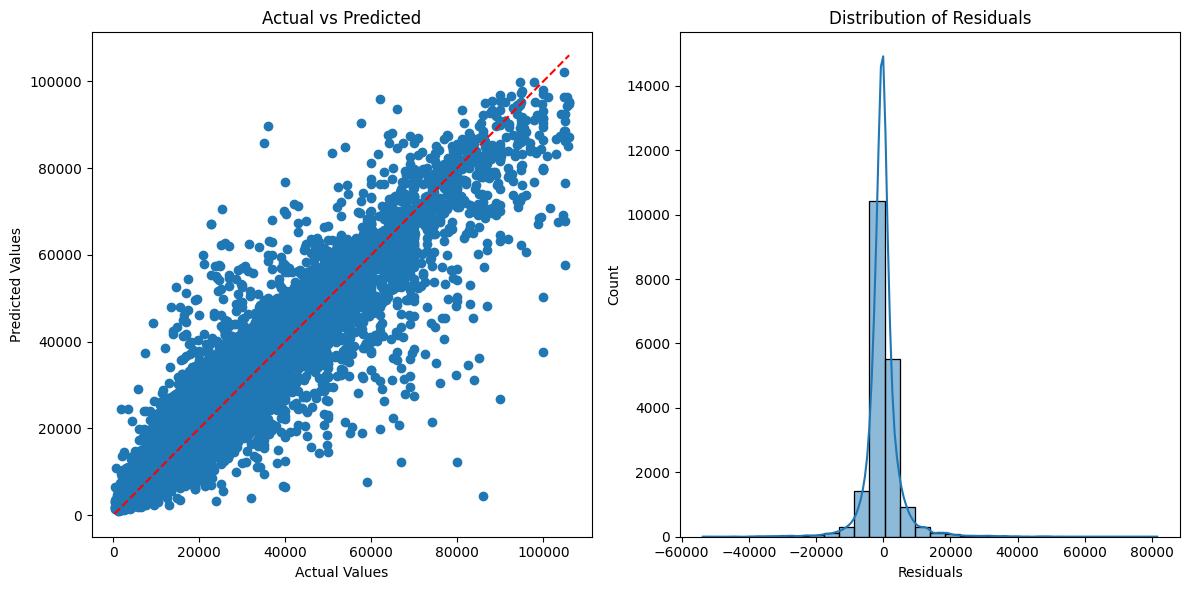

0    0.862926
Name: R2, dtype: float64
Model: GradientBoostingRegressor
R²: 0.8629257294231844, RMSE: 6313.8917282719785, MAE: 3849.950802431775


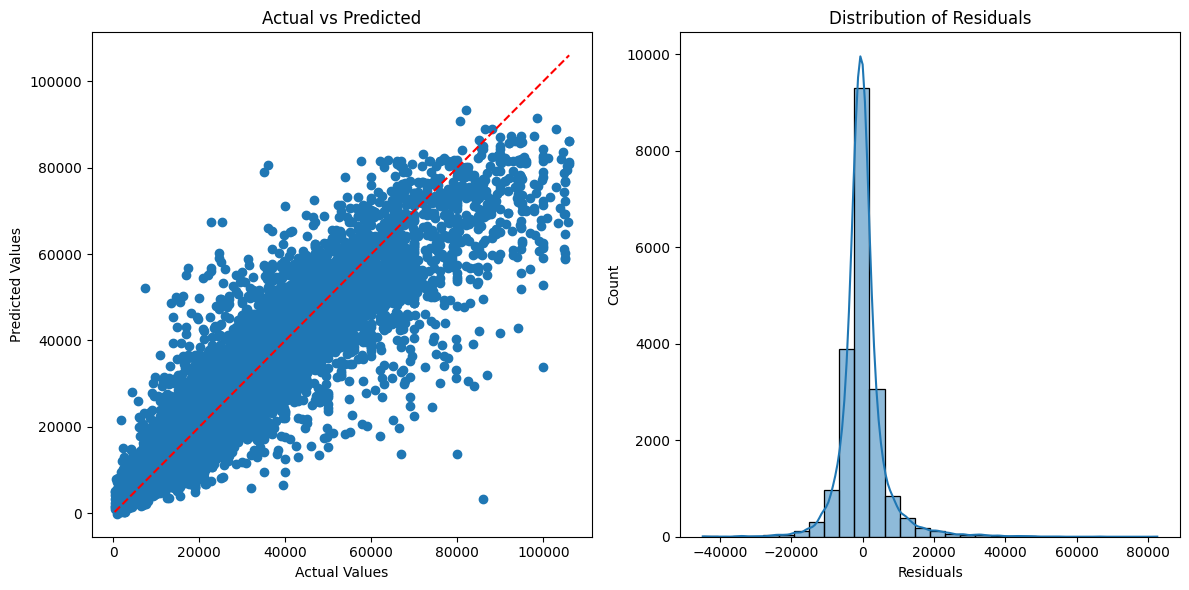

0    0.848198
Name: R2, dtype: float64
Model: PolynomialRegression
R²: 0.848197907984589, RMSE: 6644.434688079799, MAE: 4113.20384989076


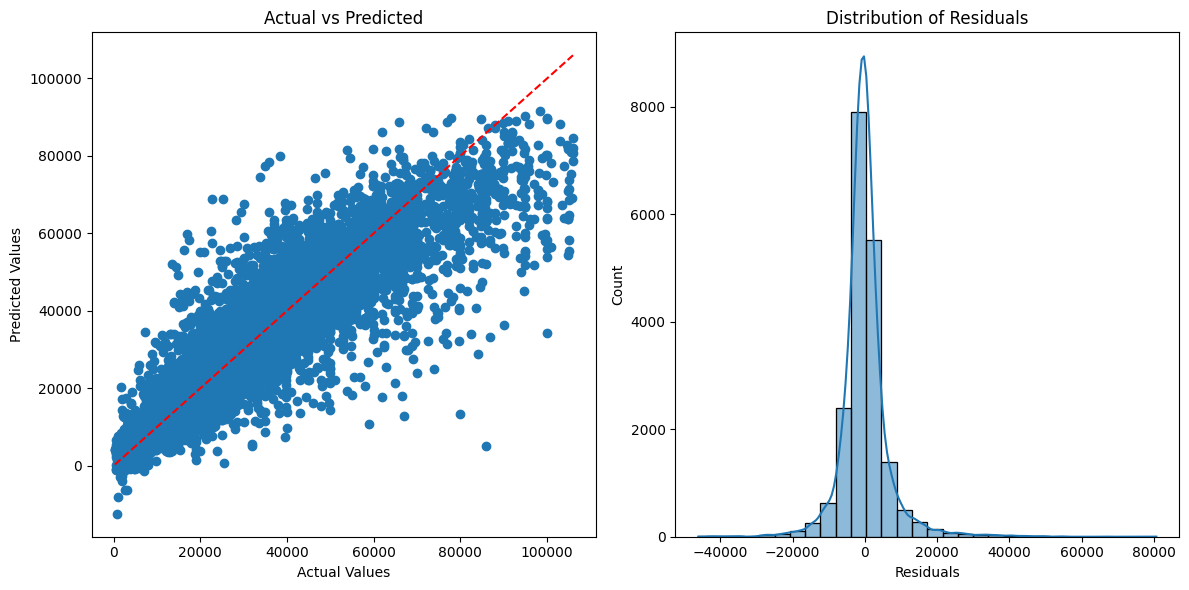

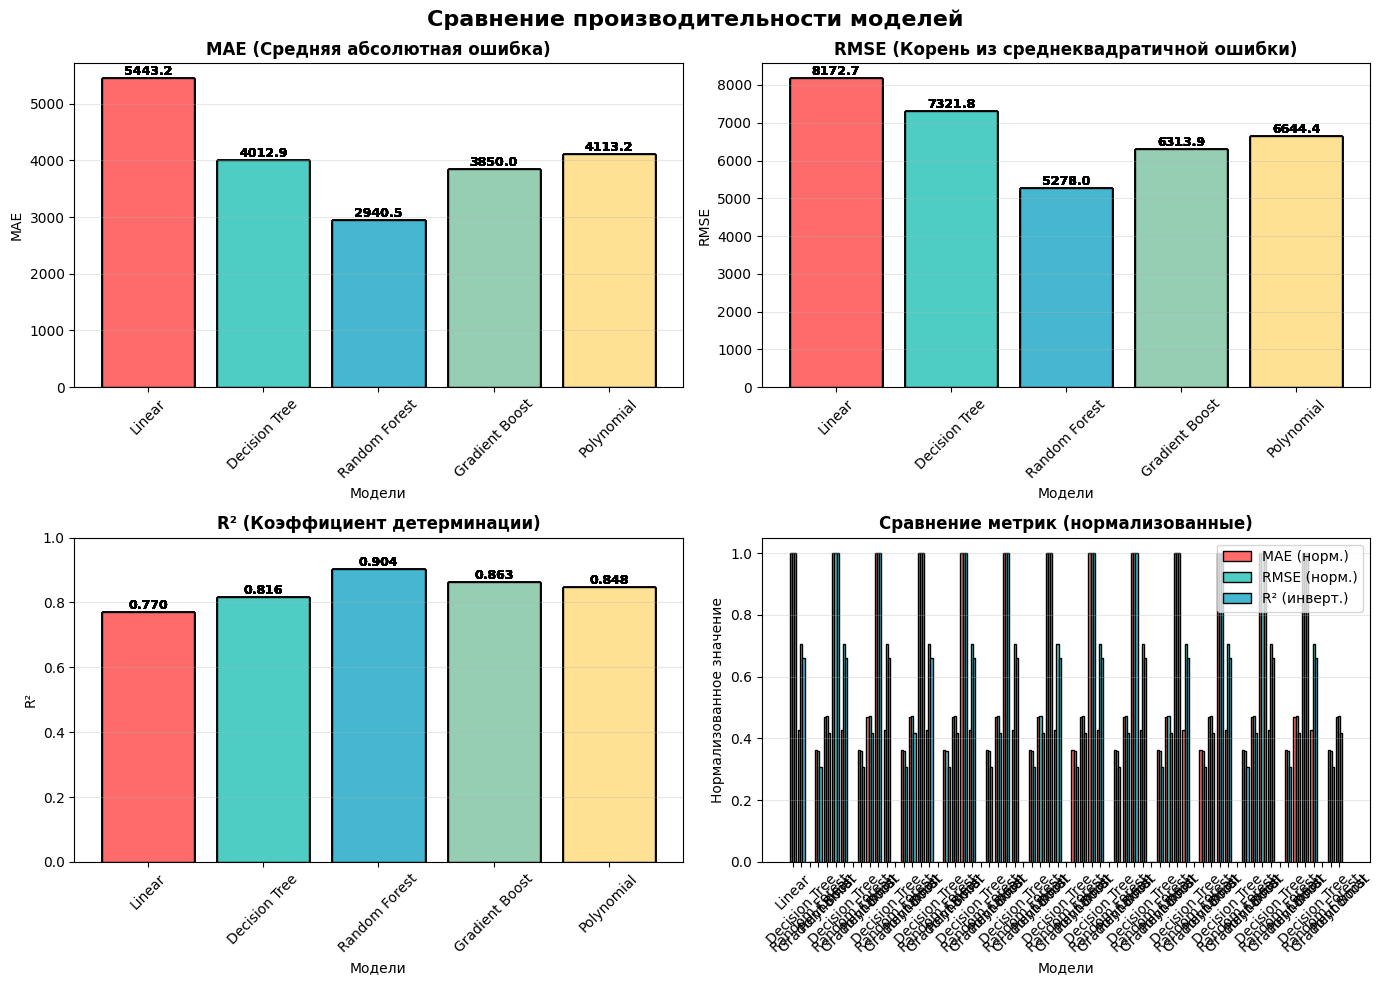

Содержимое лог-файла:
2026-03-08 16:00:23 - INFO - File: .csv загружен
2026-03-08 16:00:36 - INFO - Model: LinearRegression

2026-03-08 16:00:36 - INFO - R²: 0.770337069725441, RMSE: 8172.682160928557, MAE: 5443.226758082331
2026-03-08 16:00:38 - INFO - Model: DecisionTreeRegressor

2026-03-08 16:00:38 - INFO - R²: 0.8156710331429866, RMSE: 7321.7678213107865, MAE: 4012.8942600017667
2026-03-08 16:01:49 - INFO - Model: RandomForestRegressor

2026-03-08 16:01:49 - INFO - R²: 0.904213641137842, RMSE: 5278.01950520512, MAE: 2940.542652868186
2026-03-08 16:02:04 - INFO - Model: GradientBoostingRegressor

2026-03-08 16:02:04 - INFO - R²: 0.8629257294231844, RMSE: 6313.8917282719785, MAE: 3849.950802431775
2026-03-08 16:02:12 - INFO - Model: PolynomialRegression

2026-03-08 16:02:12 - INFO - R²: 0.848197907984589, RMSE: 6644.434688079799, MAE: 4113.20384989076
2026-03-08 16:02:13 - INFO - File: .csv загружен
2026-03-08 16:02:16 - INFO - Графики сохранены в 'model_comparison.png'
2026-03-08 1

In [ ]:
!pip install category-encoders
import get_dataset as gd
import logger as lg
import vis as v
import removing_outliers as ro
import functions as func

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import category_encoders as ce
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

global R2, RMSE, MAE

numeric_cols = ['age',
                'power_ps',
                'price_in_euro',
                'fuel_consumption_l_100km',
                'mileage_in_km']

categorical_cols = [
'brand',
'model',
'color',
'transmission_type',
'fuel_type'
]

my_results_dict = {}
lg.clear_log_file()

file_path='cleaned_data.csv'
try:
  df = pd.read_csv(file_path)
  lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
  lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

#Выявление и удаление выбросов
for col in numeric_cols:
    if col == 'price_in_euro':
        print(col," | outliers percent - ",ro.get_outliers_percent(df, col, 0.0, 0.85))
        df = ro.remove_outliers(df, col,  0.0, 0.85)
    else:
        print(col," | outliers percent - ",ro.get_outliers_percent(df, col, 0.25, 0.75))
        df = ro.rewrite_outliers(df, col, 0.25, 0.75)

v.create_histogram(df,'price_in_euro', 'Distribution of Car Prices', 'Price in Euro')
v.create_set_histogram(df, numeric_cols)

for col in categorical_cols:
    if col != 'model':
        v.create_categorical_diagram(df, col)

for col in categorical_cols:
    if col != 'model':
        v.categorical_price_plot(df, col)

raw_data = df
#энкодирование и разделение данных
df = func.encode_categorical(df, categorical_cols)

x=df.drop('price_in_euro',axis=1)
y=df['price_in_euro']
r_x=df.drop('price_in_euro',axis=1)
r_y=raw_data['price_in_euro']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=21)
rx_train,rx_test,ry_train,ry_test=train_test_split(r_x,r_y,test_size=0.2,random_state=21)

# Получение моделей для регрессии
model1 = LinearRegression()
model2 = DecisionTreeRegressor(random_state=42)
model3 = RandomForestRegressor(random_state=42)
model4 = GradientBoostingRegressor(random_state=42)
model5 = LinearRegression()

models = {
    'LinearRegression': model1,
    'DecisionTreeRegressor': model2,
    'RandomForestRegressor': model3,
    'GradientBoostingRegressor': model4,
    'PolynomialRegression' : model5
    }

for name, model in models.items():
        func.train_model_standard(model, x_train, y_train, name)
        pre = func.predict(model, x_test, x_train, name)
        func.calculate_metrics(model, x_test, y_test, pre, name)

try:
    met = pd.read_csv('metrics.csv')
    lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
    lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

func.compare_models_metrics(met, save_plots=True)


if __name__ == "__main__":
    lg.read_log_file()
